In [1]:
# E-Commerce Product Review Sentiment Analysis

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style('whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
df = pd.read_csv("ecommerce_customer_reviews_synthetic.csv")

print("Number of rows and columns:", df.shape)
df.head()

Number of rows and columns: (99441, 12)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,product_id,review_title,review_comment_message,review_score,sentiment,review_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,REV699254,PROD2613,"Poor quality, disappointed","Poor quality, disappointed.",1,Negative,2018-06-30
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,REV313841,PROD6236,"Excellent product, highly recommended","Excellent product, highly recommended.",5,Positive,2018-06-24
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,REV514540,PROD7668,Product arrived damaged,Product arrived damaged.,2,Negative,2018-01-14
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,REV687561,PROD9622,Packaging was perfect,Packaging was perfect.,5,Positive,2018-01-26
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,REV736686,PROD3986,"Excellent product, highly recommended","Excellent product, highly recommended.",4,Positive,2018-04-26


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
 5   review_id                 99441 non-null  object
 6   product_id                99441 non-null  object
 7   review_title              99441 non-null  object
 8   review_comment_message    99441 non-null  object
 9   review_score              99441 non-null  int64 
 10  sentiment                 99441 non-null  object
 11  review_date               99441 non-null  object
dtypes: int64(2), object(10)
memory usage: 9.1+ MB


In [ ]:
# Clean the data

In [6]:
df.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
review_id                   0
product_id                  0
review_title                0
review_comment_message      0
review_score                0
sentiment                   0
review_date                 0
dtype: int64

In [8]:
df = df.dropna(subset=['review_comment_message', 'review_score', 'sentiment'])

df = df.drop_duplicates()

df['review_score'] = pd.to_numeric(df['review_score'], errors='coerce')
df = df.dropna(subset=['review_score'])
df['review_score'] = df['review_score'].astype(int)
df = df[df['review_score'].between(1, 5)]

df = df.reset_index(drop=True)
print("Shape after cleaning:", df.shape)

Shape after cleaning: (99441, 12)


In [ ]:
# Explore the Data (EDA)

sentiment
Positive    59913
Negative    19823
Neutral     19705
Name: count, dtype: int64


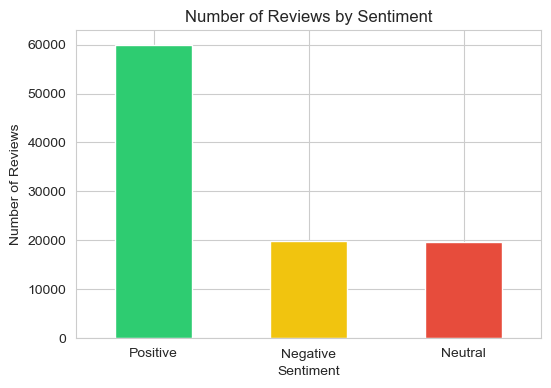

In [10]:
# How many reviews are Positive, Neutral, and Negative?

sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

plt.figure(figsize=(6, 4))
sentiment_counts.plot(kind='bar', color=['#2ecc71', '#f1c40f', '#e74c3c'])
plt.title('Number of Reviews by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

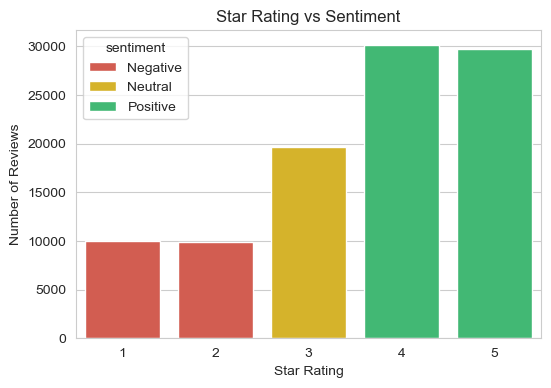

In [11]:
# How does Star Rating relate to Sentiment

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='review_score', hue='sentiment',
              palette={'Positive': '#2ecc71', 'Neutral': '#f1c40f', 'Negative': '#e74c3c'})
plt.title('Star Rating vs Sentiment')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.show()

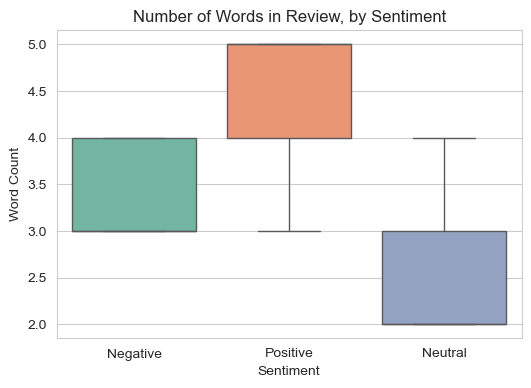

In [12]:
# How long are the reviews?

df['review_length'] = df['review_comment_message'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='sentiment', y='review_length',
            hue='sentiment', palette='Set2', legend=False)
plt.title('Number of Words in Review, by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')
plt.show()

In [13]:
# Clean the Review Text

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower() # To lowercase
    text = re.sub(r'[^a-z\s]', ' ', text) # keep only letters
    words = text.split() # split sentence into words
    words = [w for w in words if w not in stop_words]  # remove stopwords
    return ' '.join(words)

# Apply the cleaning function to every review
df['clean_review'] = df['review_comment_message'].apply(clean_text)

# Compare original vs cleaned text
df[['review_comment_message', 'clean_review']].head()

,review_comment_message,clean_review
0,"Poor quality, disappointed.",poor quality disappointed
1,"Excellent product, highly recommended.",excellent product highly recommended
2,Product arrived damaged.,product arrived damaged
3,Packaging was perfect.,packaging perfect
4,"Excellent product, highly recommended.",excellent product highly recommended


In [14]:
# Convert Text into Numbers (TF-IDF)

X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 79552
Testing samples : 19889


In [15]:
tfidf = TfidfVectorizer(max_features=3000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Shape of training data after TF-IDF:", X_train_tfidf.shape)

Shape of training data after TF-IDF: (79552, 31)


In [16]:
# Train the Model

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

print("Model training complete!")

Model training complete!


In [17]:
# Evaluate the Model

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 100.00%


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      4035
     Neutral       1.00      1.00      1.00      3926
    Positive       1.00      1.00      1.00     11928

    accuracy                           1.00     19889
   macro avg       1.00      1.00      1.00     19889
weighted avg       1.00      1.00      1.00     19889



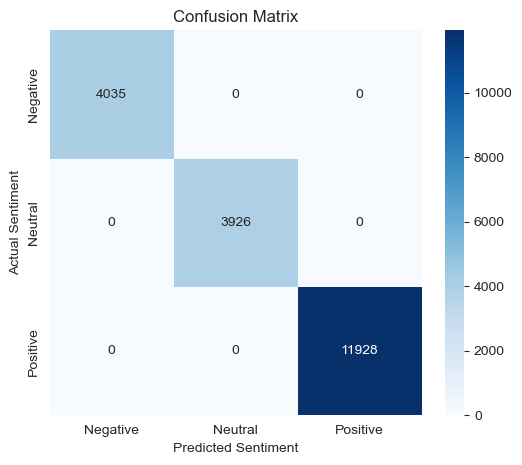

In [19]:
# A confusion matrix shows us where the model got confused
cm = confusion_matrix(y_test, y_pred, labels=['Negative', 'Neutral', 'Positive'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

In [20]:
# Test the Model on New Reviews

def predict_sentiment(review_text):
    cleaned = clean_text(review_text)
    vector = tfidf.transform([cleaned])
    prediction = model.predict(vector)
    return prediction[0]

sample_reviews = [
    "This product is amazing, I love it so much!",
    "It was okay, nothing special about it.",
    "Very bad quality, I want a refund."
]

for review in sample_reviews:
    result = predict_sentiment(review)
    print(f"Review: {review}\nPredicted Sentiment: {result}\n")

Review: This product is amazing, I love it so much!
Predicted Sentiment: Positive

Review: It was okay, nothing special about it.
Predicted Sentiment: Neutral

Review: Very bad quality, I want a refund.
Predicted Sentiment: Positive

